In [2]:
import pandas as pd
url = 'https://frenzy86.s3.eu-west-2.amazonaws.com/python/data/Startup.csv'
df = pd.read_csv(url)
df.to_csv('C:/Users/0304f/Downloads/Startup.csv', index=False)

In [3]:
df

,R&D Spend,Administration,Marketing Spend,Profit
0,165349.20,136897.80,471784.10,192261.83
1,162597.70,151377.59,443898.53,191792.06
2,153441.51,101145.55,407934.54,191050.39
3,144372.41,118671.85,383199.62,182901.99
4,142107.34,91391.77,366168.42,166187.94
5,131876.90,99814.71,362861.36,156991.12
6,134615.46,147198.87,127716.82,156122.51
7,130298.13,145530.06,323876.68,155752.60
8,120542.52,148718.95,311613.29,152211.77
9,123334.88,108679.17,304981.62,149759.96


<Axes: xlabel='Marketing Spend', ylabel='Profit'>

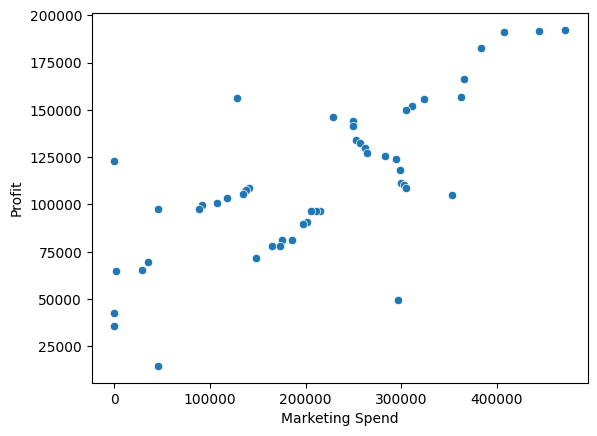

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
x=df["Marketing Spend"]
y=df["Profit"]
sns.scatterplot(x=x, y=y)

In [5]:
df.corr()

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: xlabel='R&D Spend', ylabel='Profit'>

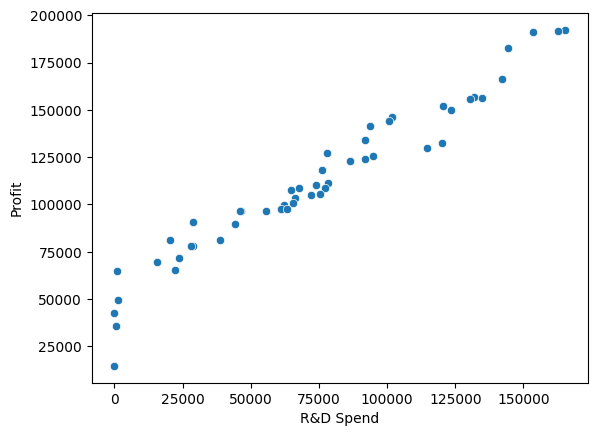

In [6]:
x=df["R&D Spend"]
y=df["Profit"]
sns.scatterplot(x=x, y=y)

In [7]:
import statsmodels.api as sm
X = sm.add_constant(df['R&D Spend'])
y = df['Profit']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     849.8
Date:                Mon, 28 Oct 2024   Prob (F-statistic):           3.50e-32
Time:                        09:13:07   Log-Likelihood:                -527.44
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      48   BIC:                             1063.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.903e+04   2537.897     19.320      0.0

In [8]:
#REGRESSIONE LINEARE
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df[['R&D Spend']]
y = df['Profit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scelta del modello e 4. Stima dei parametri
model = LinearRegression()
model.fit(X_train, y_train)
print('Coefficiente:', model.coef_[0])
print('Intercetta:', model.intercept_)

# Previsioni sul set di test
y_pred = model.predict(X_test)

# Risultati
for i in range(len(y_test)):
    print(f"Reale: {y_test.iloc[i]}, Predetto: {y_pred[i]}")

Coefficiente: 0.8536091075148801
Intercetta: 49336.66803799113
Reale: 134307.35, Predetto: 127862.2099640519
Reale: 81005.76, Predetto: 82250.56334619471
Reale: 99937.59, Predetto: 102255.72078164021
Reale: 64926.08, Predetto: 50190.47347560074
Reale: 125370.37, Predetto: 130136.88190548433
Reale: 35673.41, Predetto: 49799.36685471957
Reale: 105733.54, Predetto: 113638.07752879555
Reale: 107404.34, Predetto: 104535.05342879967
Reale: 97427.84, Predetto: 103463.0484311271
Reale: 122776.86, Predetto: 123105.3110266948


In [12]:
#REGRESSIONE MULTIPLA
X = df[['R&D Spend', 'Administration','Marketing Spend']]
y = df['Profit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
B0=model.intercept_
B1,B2,B3=model.coef_
print(B0,B1,B2,B3)

54071.87574599086 0.803779275629752 -0.06792917400149986 0.03124154589773294


In [14]:
df.to_excel('Startup.xlsx', index=False)